# Confidence Intervals

## Learning Objectives

By the end of this notebook you will be able to:

1. Define and correctly interpret **frequentist confidence intervals**.
2. Derive CIs for the Normal mean (known and unknown $\sigma$) using **pivotal quantities**.
3. Construct CIs from the **asymptotic normality of the MLE**.
4. Implement the **bootstrap** for nonparametric CIs — from scratch.
5. Avoid the most common **misinterpretation** of confidence intervals.

## Prerequisites

- [03_maximum_likelihood.ipynb](03_maximum_likelihood.ipynb) — MLE, Fisher information, asymptotic normality
- [Module 02](../02_distributions/02_continuous_distributions.ipynb) — Normal distribution, Student's $t$

In [ ]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim ipython==8.21.0"
    )

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)

    def apply_manim_config(self):
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr, **kwargs):
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        return Text(expr, **kwargs)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  ✓ media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

---

## 1. What Is a Confidence Interval?

A point estimate $\hat{\theta}$ gives a single "best guess" for $\theta$. But how uncertain is it? A **confidence interval** (CI) provides a range.

> **Definition.** A **$100(1-\alpha)\%$ confidence interval** for $\theta$ is a random interval $[L, U]$ (computed from data) such that:
>
> $$P(L \leq \theta \leq U) = 1 - \alpha$$
>
> The probability is over repeated sampling — $\theta$ is fixed, the interval is random.

### The correct interpretation

If we repeated the experiment many times and computed a 95% CI each time, **about 95% of those intervals would contain the true $\theta$**. Any single interval either contains $\theta$ or it doesn't — we just don't know which.

### The common misinterpretation

A 95% CI does **NOT** mean "there is a 95% probability that $\theta$ is in this interval." The parameter $\theta$ is a fixed number, not a random variable. (The Bayesian credible interval in Module 07 does make this statement — one reason people find Bayesian inference more intuitive.)

---

## 2. CI for the Normal Mean (Known $\sigma$)

If $X_1, \dots, X_n \sim \mathcal{N}(\mu, \sigma^2)$ with $\sigma$ known, then $\bar{X} \sim \mathcal{N}(\mu, \sigma^2/n)$, so:

$$Z = \frac{\bar{X} - \mu}{\sigma/\sqrt{n}} \sim \mathcal{N}(0, 1)$$

A $100(1-\alpha)\%$ CI is:

$$\bar{x} \pm z_{\alpha/2} \cdot \frac{\sigma}{\sqrt{n}}$$

where $z_{\alpha/2}$ is the $(1-\alpha/2)$ quantile of $\mathcal{N}(0,1)$ (e.g., $z_{0.025} = 1.96$ for 95%).

### CI for the Normal mean (Unknown $\sigma$)

In practice, $\sigma$ is unknown. Replacing it with the sample standard deviation $s$ introduces extra uncertainty. The pivotal quantity becomes:

$$T = \frac{\bar{X} - \mu}{S/\sqrt{n}} \sim t_{n-1}$$

where $t_{n-1}$ is the **Student's $t$-distribution** with $n-1$ degrees of freedom. The CI is:

$$\bar{x} \pm t_{\alpha/2, n-1} \cdot \frac{s}{\sqrt{n}}$$

For large $n$, $t_{n-1} \approx \mathcal{N}(0,1)$ and the two formulas coincide.

In [2]:
# From scratch: confidence interval for Normal mean
def ci_normal_mean(data, confidence=0.95):
    """CI for the mean using the t-distribution (unknown σ)."""
    n = len(data)
    xbar = np.mean(data)
    se = np.std(data, ddof=1) / np.sqrt(n)
    t_crit = stats.t.ppf((1 + confidence) / 2, df=n - 1)
    return xbar - t_crit * se, xbar + t_crit * se


# Example
sample = rng.normal(loc=100, scale=15, size=30)
lo, hi = ci_normal_mean(sample)
print(f"Sample mean: {np.mean(sample):.2f}")
print(f"95% CI:      [{lo:.2f}, {hi:.2f}]")
print(f"True μ = 100 — {'inside ✓' if lo <= 100 <= hi else 'outside ✗'}")

Sample mean: 100.25
95% CI:      [95.90, 104.60]
True μ = 100 — inside ✓


### Repeated sampling: verifying the coverage

The defining property: across many experiments, 95% of 95% CIs contain the true $\mu$. The plot below generates 100 CIs and checks which ones cover the true value.

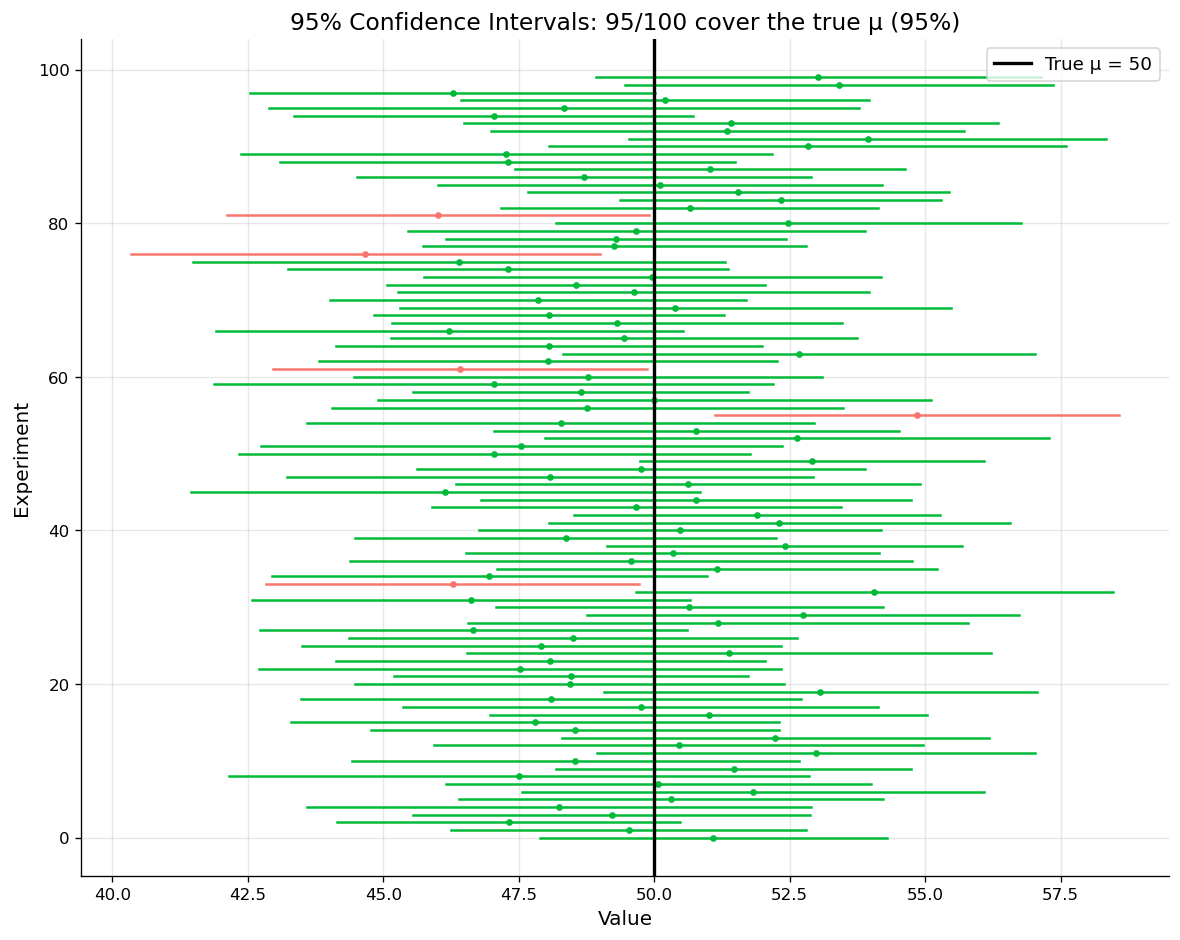

In [ ]:
# Repeated-sampling demonstration of CI coverage
true_mu = 50
true_sigma = 10
n = 25
n_experiments = 100
confidence = 0.95

fig, ax = plt.subplots(figsize=(10, 8))

covers = 0
for i in range(n_experiments):
    sample = rng.normal(true_mu, true_sigma, n)
    lo, hi = ci_normal_mean(sample, confidence)
    color = "#00BA38" if lo <= true_mu <= hi else "#F8766D"
    ax.plot([lo, hi], [i, i], color=color, linewidth=1.5)
    ax.plot(np.mean(sample), i, "o", color=color, markersize=3)
    if lo <= true_mu <= hi:
        covers += 1

ax.axvline(
    true_mu, color="black", linewidth=2, linestyle="-", label=f"True μ = {true_mu}"
)
ax.set_xlabel("Value")
ax.set_ylabel("Experiment")
ax.set_title(
    f"95% Confidence Intervals: {covers}/{n_experiments} cover the true μ ({covers}%)"
)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

Green intervals contain the true $\mu$; red ones miss it. About 95% are green — exactly as the theory predicts. The 5% that miss are not errors — they're the expected rate of non-coverage.

---

## 3. Asymptotic CIs from the MLE

For any MLE with asymptotic normality (notebook 03, section 6):

$$\hat{\theta} \approx \mathcal{N}\left(\theta, \frac{1}{I_n(\hat{\theta})}\right)$$

An approximate $100(1-\alpha)\%$ CI is:

$$\hat{\theta} \pm z_{\alpha/2} \cdot \frac{1}{\sqrt{I_n(\hat{\theta})}}$$

This is called the **Wald interval**. It works for any parameter estimated by MLE, not just the Normal mean.

In [ ]:
# Wald CI for Exponential rate λ
exp_data = rng.exponential(scale=1 / 3, size=100)  # true λ = 3
lam_hat = 1 / np.mean(exp_data)  # MLE

# Fisher info for Exp: I(λ) = 1/λ², so I_n = n/λ̂², SE = λ̂/√n
se_lam = lam_hat / np.sqrt(len(exp_data))
z = stats.norm.ppf(0.975)

print(f"MLE: λ̂ = {lam_hat:.4f}")
print(f"95% Wald CI: [{lam_hat - z * se_lam:.4f}, {lam_hat + z * se_lam:.4f}]")
print(f"True λ = 3")

MLE: λ̂ = 2.9990
95% Wald CI: [2.4112, 3.5867]
True λ = 3


---

## 4. The Bootstrap — Nonparametric Confidence Intervals

What if we don't know the distribution? The **bootstrap** (Efron, 1979) constructs CIs by resampling the data itself.

### The idea

1. From the original sample of size $n$, draw $B$ **bootstrap samples** — each of size $n$, sampled **with replacement**.
2. Compute the statistic $\hat{\theta}^*_b$ on each bootstrap sample.
3. Use the distribution of $\hat{\theta}^*_1, \dots, \hat{\theta}^*_B$ to estimate the sampling distribution of $\hat{\theta}$.

### The percentile method

The simplest bootstrap CI: take the $\alpha/2$ and $1 - \alpha/2$ percentiles of the bootstrap distribution.

$$\text{CI}_{\text{boot}} = \left[\hat{\theta}^*_{(\alpha/2)},\; \hat{\theta}^*_{(1-\alpha/2)}\right]$$

Bootstrap 95% CI: [46.71, 53.44]
t-based 95% CI:   [46.39, 53.60]


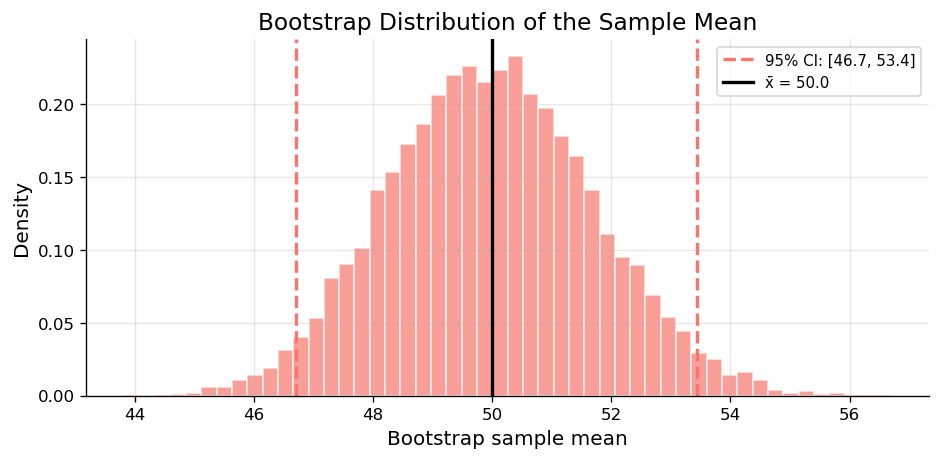

In [ ]:
# Stage 2: FROM SCRATCH — bootstrap CI
def bootstrap_ci(data, statistic, B=10_000, confidence=0.95):
    """Percentile bootstrap CI for any statistic."""
    n = len(data)
    boot_stats = np.array(
        [statistic(rng.choice(data, size=n, replace=True)) for _ in range(B)]
    )
    alpha = 1 - confidence
    lo = np.percentile(boot_stats, 100 * alpha / 2)
    hi = np.percentile(boot_stats, 100 * (1 - alpha / 2))
    return lo, hi, boot_stats


# Bootstrap CI for the mean
sample = rng.normal(loc=50, scale=10, size=30)
lo_b, hi_b, boot_means = bootstrap_ci(sample, np.mean)
lo_t, hi_t = ci_normal_mean(sample)

print(f"Bootstrap 95% CI: [{lo_b:.2f}, {hi_b:.2f}]")
print(f"t-based 95% CI:   [{lo_t:.2f}, {hi_t:.2f}]")

# Plot bootstrap distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot_means, bins=50, density=True, alpha=0.7, edgecolor="white")
ax.axvline(
    lo_b,
    color="#F8766D",
    linewidth=2,
    linestyle="--",
    label=f"95% CI: [{lo_b:.1f}, {hi_b:.1f}]",
)
ax.axvline(hi_b, color="#F8766D", linewidth=2, linestyle="--")
ax.axvline(
    np.mean(sample), color="black", linewidth=2, label=f"x̄ = {np.mean(sample):.1f}"
)
ax.set_xlabel("Bootstrap sample mean")
ax.set_ylabel("Density")
ax.set_title("Bootstrap Distribution of the Sample Mean")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

The bootstrap CI and the t-based CI are very similar for the Normal mean — because the Normal case is where the t-based CI is exact. The bootstrap shines when the analytical formula is unknown.

In [6]:
# Bootstrap for the MEDIAN — no simple analytical CI exists
skewed_data = rng.exponential(scale=5, size=40)

lo_med, hi_med, boot_medians = bootstrap_ci(skewed_data, np.median)
print(f"Sample median: {np.median(skewed_data):.2f}")
print(f"Bootstrap 95% CI for median: [{lo_med:.2f}, {hi_med:.2f}]")
print(f"True median (Exponential): {5 * np.log(2):.2f}")

Sample median: 2.70
Bootstrap 95% CI for median: [1.98, 4.24]
True median (Exponential): 3.47


There's no clean formula for the CI of a median from skewed data. The bootstrap handles it effortlessly — just resample and compute the median each time. This generality is the bootstrap's greatest strength.

---

## 5. CI Width and Sample Size

The CI width depends on three things:

1. **Confidence level** $(1-\alpha)$: higher confidence → wider interval (more certainty costs precision).
2. **Sample size** $n$: more data → narrower interval ($\propto 1/\sqrt{n}$).
3. **Variability** $\sigma$: more spread → wider interval.

This leads to a practical question: **how large must $n$ be** to achieve a desired precision? For the Normal mean:

$$n \geq \left(\frac{z_{\alpha/2} \cdot \sigma}{\text{margin}}\right)^2$$

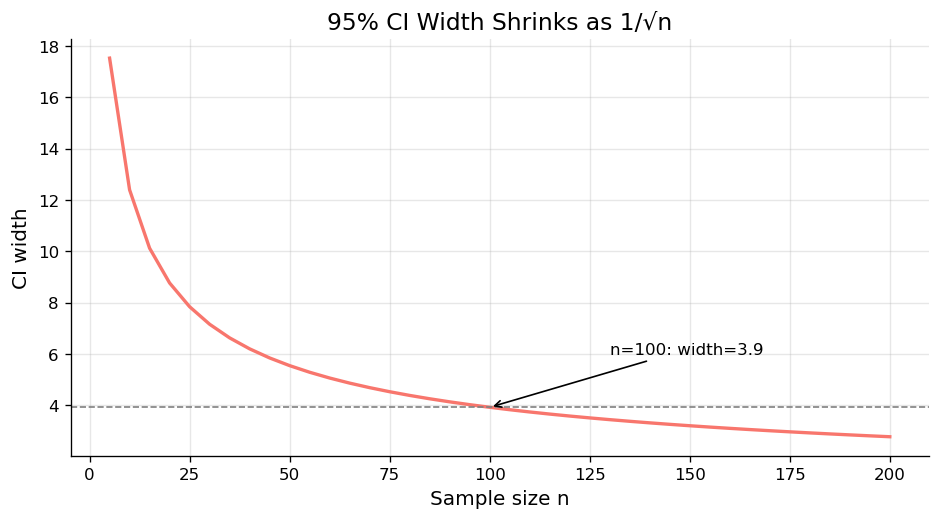

In [ ]:
# CI width vs. sample size
ns = np.arange(5, 201, 5)
sigma = 10
z95 = stats.norm.ppf(0.975)

widths = 2 * z95 * sigma / np.sqrt(ns)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(ns, widths, linewidth=2)
ax.axhline(2 * z95 * sigma / np.sqrt(100), color="grey", linestyle="--", linewidth=1)
ax.annotate(
    f"n=100: width={2 * z95 * sigma / 10:.1f}",
    xy=(100, 2 * z95 * sigma / 10),
    xytext=(130, 6),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10,
)
ax.set_xlabel("Sample size n")
ax.set_ylabel("CI width")
ax.set_title("95% CI Width Shrinks as 1/√n")
plt.tight_layout()
plt.show()

Doubling the precision (halving the CI width) requires **four times** the data. This $1/\sqrt{n}$ scaling is fundamental and applies to most CIs.

---

## Exercises

**Exercise 4.1 (t-interval).** Generate 20 samples from $\mathcal{N}(10, 4)$. Compute 90%, 95%, and 99% CIs. How does the width change?

**Exercise 4.2 (Coverage simulation).** Repeat the coverage experiment (Section 2) with $n = 5$ instead of $n = 25$. Does the 95% CI still achieve 95% coverage? What changes about the interval widths?

**Exercise 4.3 (Bootstrap for correlation).** Generate 50 pairs $(X, Y)$ with known correlation $\rho = 0.6$. Compute the sample correlation $r$ and its bootstrap 95% CI.

**Exercise 4.4 (Sample size planning).** You want to estimate a population mean with $\sigma \approx 20$ to within $\pm 3$ at 95% confidence. What is the minimum sample size?

**Exercise 4.5 (Wald vs. bootstrap).** For $X \sim \text{Exponential}(\lambda = 2)$, compare the Wald CI for $\lambda$ (from the MLE) with the bootstrap percentile CI, using $n = 20$. Run 5,000 experiments and compare their actual coverage rates.

**Exercise 4.6 (Challenge — BCa bootstrap).** The percentile method can have poor coverage for skewed statistics. The **bias-corrected and accelerated (BCa)** method improves this. Implement BCa using the formulas in Efron & Tibshirani (1993) and compare coverage with the percentile method for the median of $\text{Exponential}(1)$ data.

---

## Key Takeaways

1. A **confidence interval** $[L, U]$ is a random interval that contains the true $\theta$ with probability $1-\alpha$ over repeated sampling.
2. For the Normal mean: use $\bar{x} \pm t_{\alpha/2, n-1} \cdot s/\sqrt{n}$ (t-based, exact for Normal data).
3. For any MLE: use $\hat{\theta} \pm z_{\alpha/2} / \sqrt{I_n(\hat{\theta})}$ (Wald interval, asymptotic).
4. The **bootstrap** builds CIs by resampling — no distributional assumptions needed. It works for any statistic.
5. CI width scales as $1/\sqrt{n}$ — doubling precision requires quadrupling data.
6. **Interpretation:** "95% of similarly constructed intervals would contain $\theta$" — NOT "there's a 95% chance $\theta$ is in this interval."

**This completes Module 04: Estimation.** You can now estimate parameters (point estimates), quantify their precision (CIs), and do so both analytically and computationally.

**Next:** [Module 05 — Hypothesis Testing](../05_hypothesis_testing/01_hypothesis_framework.ipynb) — Testing claims about parameters: is the effect real, or just noise?

In [8]:
cfg.save_gifs(clean=True)

  ✓ media/gifs/BiasVarianceDartboard@2026-03-19@16-26-55.gif
  Cleaned up local temp render files (kept media/jupyter/).
